# Overview 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

In [2]:
sns.set_theme(style="darkgrid")
colors = edgecolors = sns.color_palette("flare")


In [3]:
# global attribute
# per le lettere
offset = 5
plt.rcParams["font.family"] = "DIN Alternate"
plt.rcParams["axes.titlesize"] = 20 + offset
plt.rcParams["axes.labelsize"] = 15 + offset
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["xtick.labelsize"]   = 15 + offset
plt.rcParams["ytick.labelsize"]   = 15 + offset
plt.rcParams["legend.fontsize"]   = 15 + offset
plt.rcParams["legend.title_fontsize"] = 15 + offset

# per il colore del grafico 
plt.rcParams["axes.facecolor"] = "white"
#plt.rcParams["figure.facecolor"] =  "#ca6702"
plt.rcParams["grid.color"] = "#fed0bb"
plt.rcParams["axes.edgecolor"] = "#fed0bb"


In [2]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name_strict.csv"
df = pd.read_csv(RESULT_TOT)
print(df.columns)
df['model'].unique()

Index(['model', 'language', 'messaggi', 'ore_ordinarie_true',
       'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true', 'chat_context',
       'function_calls', 'push_data_response', 'ore_ordinarie_acc',
       'ore_straordinarie_acc', 'ore_viaggio_acc', 'inefficiency_acc',
       'tot_acc', 'ore_ordinarie_predict', 'ore_straordinarie_predict',
       'ore_viaggio_predict', 'note_predict', 'inefficiency_predict',
       'inefficiency_note_predict', 'REF_INDICE', 'L_MESSAGGI', 'TYPE_EVAL',
       'count_function_calls', 'failure_reason',
       'sentence_similarity_score_note',
       'sentence_similarity_score_inefficiency', 'n_relevant_fields'],
      dtype='str')


<ArrowStringArray>
[                   'qwen-chat-agent-4-v2',
                          'chat-qwen-base',
                       'qwen-chat-agent-6',
                        'qwen-extractor-3',
                        'qwen-extractor-4',
                        'qwen-extractor-2',
    'qwen-chat-extractor-tuned-lora-16-v1',
                    'qwen-chat-agent-5-v1',
                       'qwen-chat-agent-7',
          'qwen-chat-agent-8-wo-embedding',
                      'qwen-chat-agent-12',
                       'qwen-chat-agent-9',
                'qwen-extractor-5-lora-32',
              'qwen-extractor-6-embedding',
 'qwen_chat_agent_13_dense_reward_30_step',
         'qwen_chat_agent_13_dense_reward',
                     'qwen_chat_agent_sft',
                      'qwen_extractor_sft',
                       'qwen_combined_sft',
                      'qwen_combined_grpo']
Length: 20, dtype: str

# Mean computation change

In [4]:
target ='qwen-chat-agent-4-v2|chat-qwen-base|qwen-chat-agent-5-v1|qwen-chat-agent-8-wo-embedding|qwen_chat_agent_13_dense_reward|qwen_chat_agent_sft'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-base','agent-sparse','agent-dense-v2(step 32)','agent-dense-v2(step 51)']
colors = cm.tab10.colors
models

['qwen-chat-agent-4-v2',
 'chat-qwen-base',
 'qwen-chat-agent-5-v1',
 'qwen-chat-agent-8-wo-embedding',
 'qwen_chat_agent_13_dense_reward_30_step',
 'qwen_chat_agent_13_dense_reward',
 'qwen_chat_agent_sft']

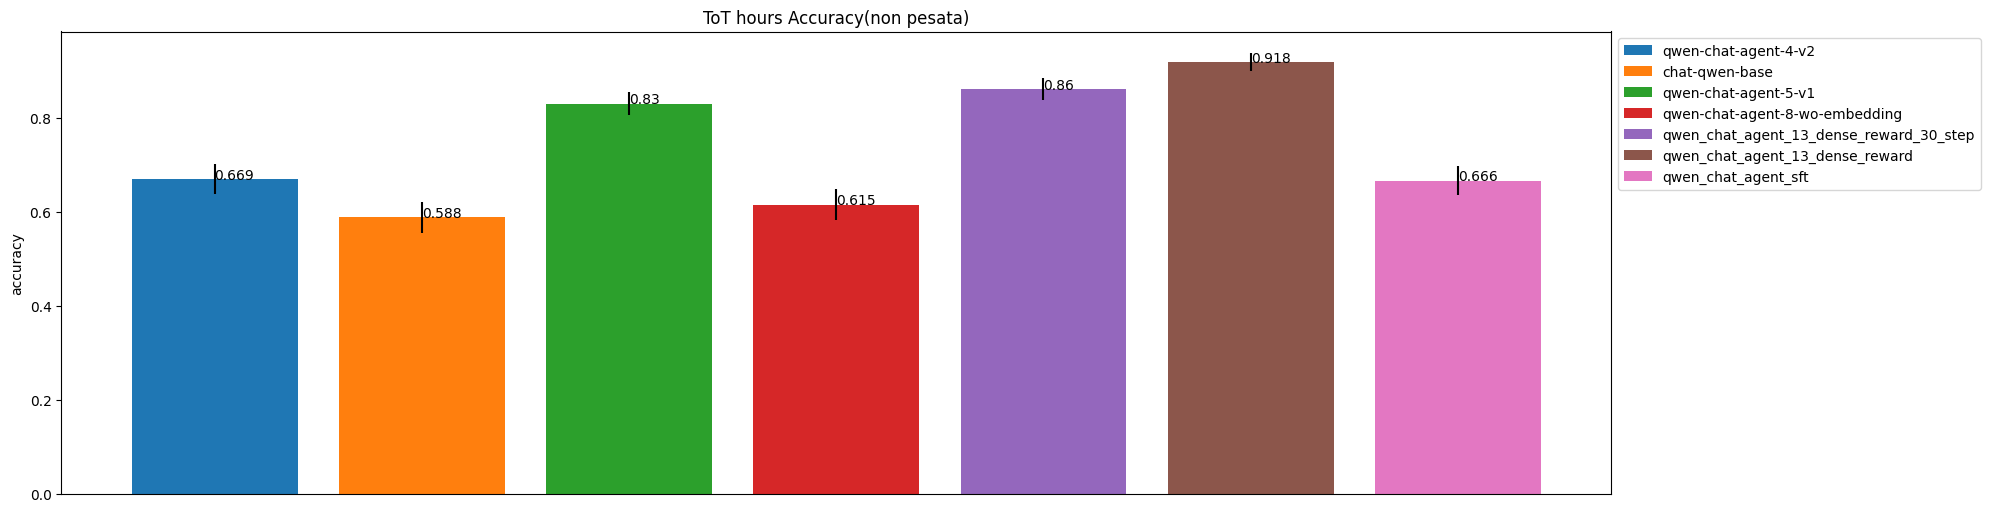

In [5]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)]['tot_acc'].mean(),3)
    n = len(df.loc[(df['model'] == model)])
    # intervallo di confidenza al 90 %
    CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors , label=models)
add_labels(models,media_group)
plt.title("ToT hours Accuracy(non pesata)")
plt.xticks([])
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

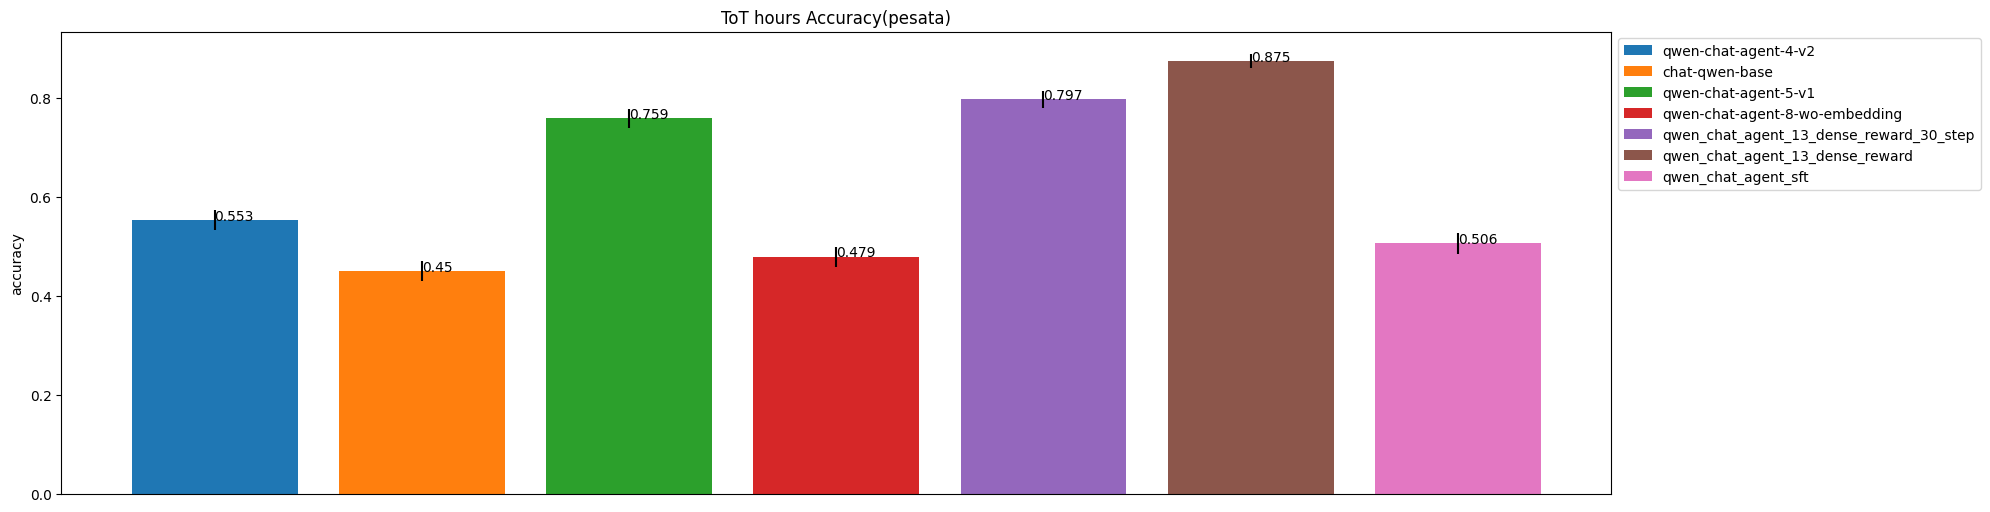

In [6]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    g = df.loc[df['model'] == model]
    acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
      )                                                                                                                                                                                                                                                                                                      
    # effective n = total field evaluations (not number of rows)                                                                                          
    n = g['n_relevant_fields'].sum()
    # intervallo di confidenza al 90 %
    CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors , label=models)
add_labels(models,media_group)
plt.title("ToT hours Accuracy(pesata)")
plt.xticks([])
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Dense reward by relevant fields

In [ ]:
target ='base|qwen-chat-agent-5-v1|qwen_chat_agent_13_dense_reward_30_step|qwen_chat_agent_13_dense_reward'
models = list(df[df['model'].str.contains(target)]['model'].unique())

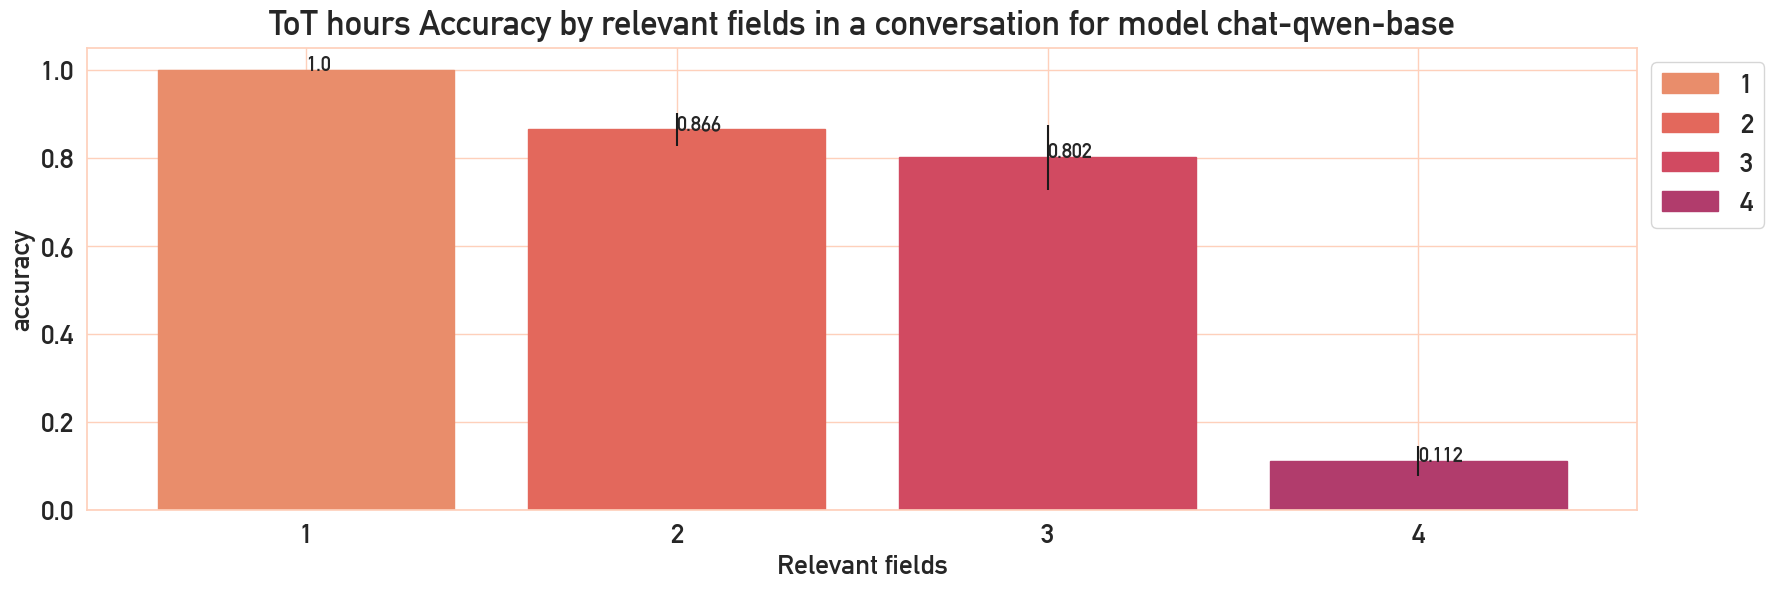

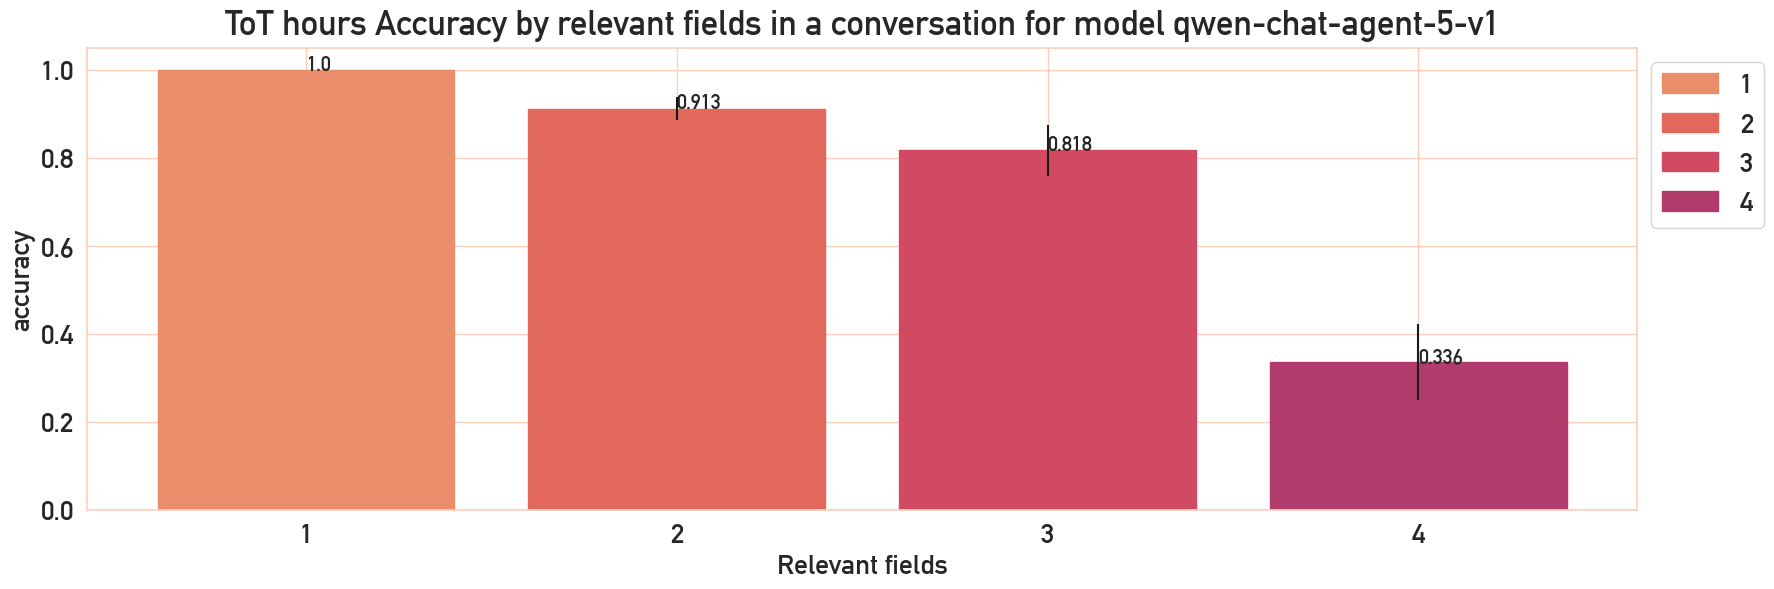

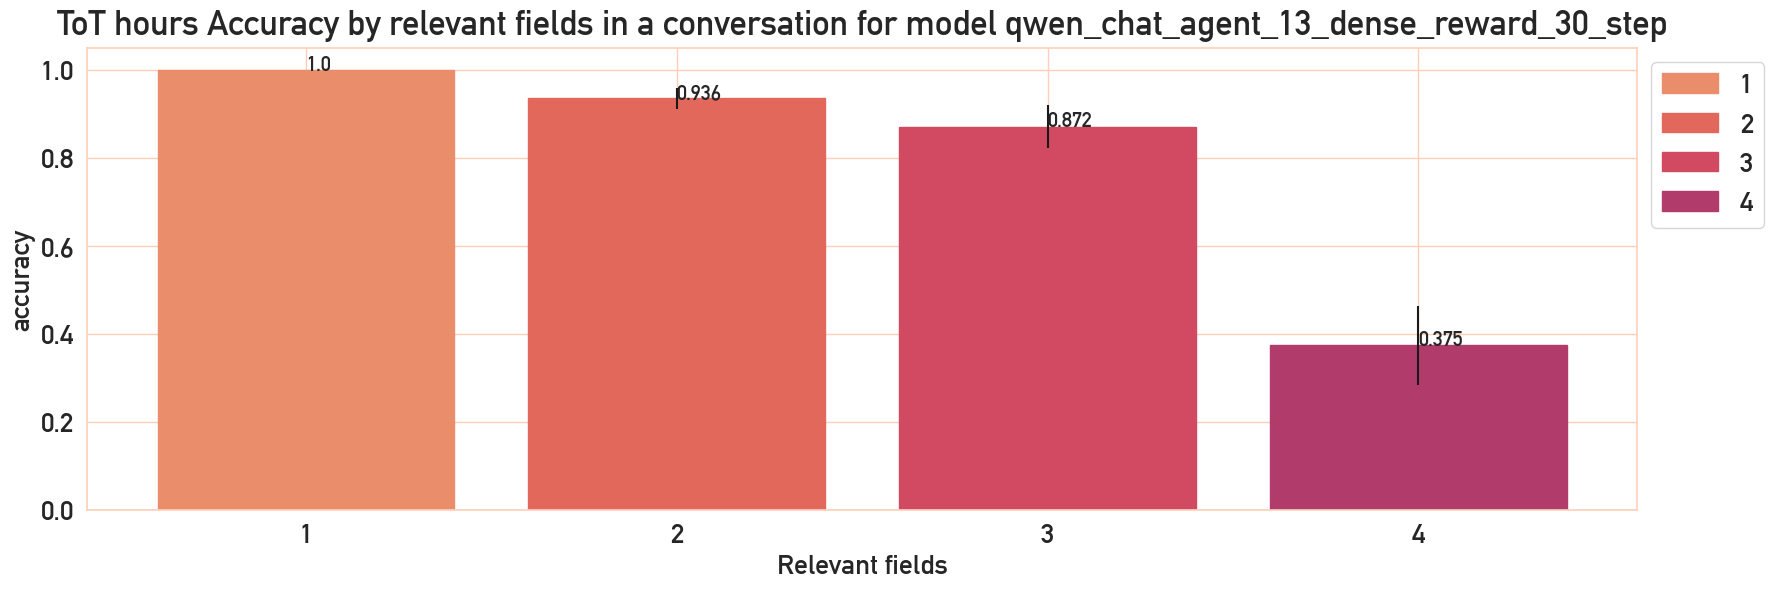

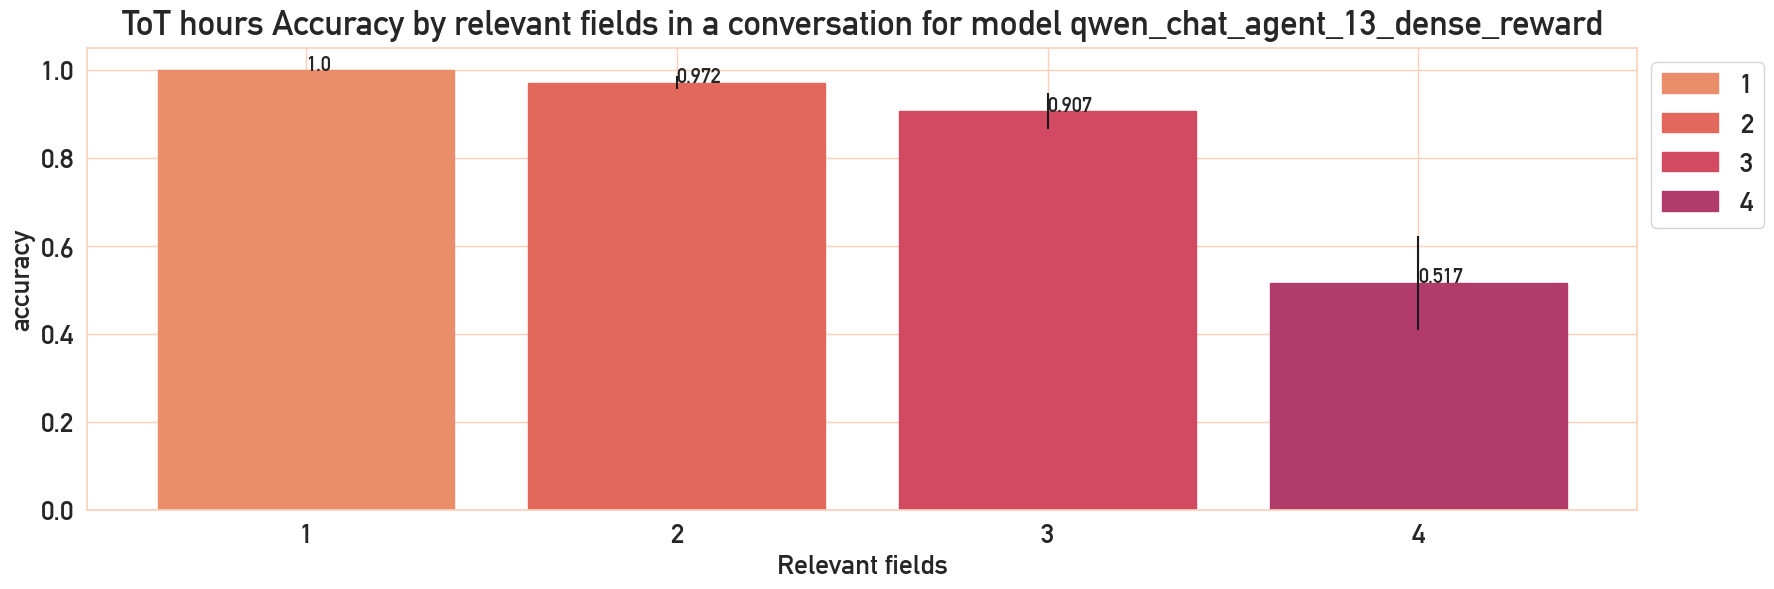

In [6]:
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    media_group = []
    CI_group = []
    n_fields = np.sort(df['n_relevant_fields'].unique())[1:]
    for n_field in n_fields:
        acc_media = round(df.loc[(df['model'] == model)  & (df['n_relevant_fields'] == n_field)]['tot_acc'].mean(),3)
        n = len(df.loc[(df['model'] == model)  & (df['n_relevant_fields'] == n_field)])
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(n_fields,media_group, yerr=CI_group, label=n_fields, color=colors, edgecolor=colors)
    add_labels(n_fields,media_group)
    plt.title(f"ToT hours Accuracy by relevant fields in a conversation for model {model}", pad=10)
    plt.xlabel("Relevant fields")
    plt.xticks(n_fields)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True)